# Comparison of Radial Profiles: IO vs NIO vs Observations

Comparing: NGC2403, NGC2841, UGC05721

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
# from scipy.interpolate import interp1d
from fractions import Fraction

BASE_DIR = Path("..")
IO_DIR = BASE_DIR / "outputs" / "model_radial_profiles" / "io"
NIO_DIR = BASE_DIR / "outputs" / "model_radial_profiles" / "nio"
HI_DIR = BASE_DIR / "data" / "allHIprofs_mod"
SFR_DIR = BASE_DIR / "data" / "allSFRprofs"
STARS_DIR = BASE_DIR / "data" / "allSTARSprofs"

plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

In [2]:
def load_model_profile(filepath):
    data = np.load(filepath, allow_pickle=True)
    return {key: data[key] for key in data.files}

def load_observed_HI(galaxy_name):
    filepath = HI_DIR / f"{galaxy_name}_fullHI.dat"
    if not filepath.exists(): return None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 2]

def load_observed_SFR(galaxy_name):
    filepath = SFR_DIR / f"{galaxy_name}_R_Vrot_SigmaGas_SigmaSFR.txt"
    if not filepath.exists(): return None, None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 3]/1e6, data[:, 5]*1e9/1e6

def load_observed_stars(galaxy_name):
    filepath = STARS_DIR / f"{galaxy_name}_fullstars.dat"
    if not filepath.exists(): return None, None
    data = np.genfromtxt(filepath, skip_header=1)
    return data[:, 0], data[:, 3]

def get_profile_at_t0(profile, key):
    arr = profile[key]
    return arr[:, -1] if arr.ndim == 2 else arr

In [3]:
GALAXIES = ["NGC3627", "UGC04278"]#["NGC2403", "NGC2841", "DDO50"]
profiles = {}

for gal in GALAXIES:
    profiles[gal] = {"io": None, "nio": None, "obs_HI": None, "obs_SFR": None, "obs_stars": None}
    
    io_file = IO_DIR / f"{gal}_profile.npz"
    if io_file.exists():
        profiles[gal]["io"] = load_model_profile(io_file)
        print(f"{gal}: Loaded IO model")
    
    nio_file = NIO_DIR / f"{gal}_profile.npz"
    if nio_file.exists():
        profiles[gal]["nio"] = load_model_profile(nio_file)
        print(f"{gal}: Loaded NIO model")
    
    r_hi, sigma_hi = load_observed_HI(gal)
    if r_hi is not None:
        profiles[gal]["obs_HI"] = {"r_kpc": r_hi, "Sigma_HI": sigma_hi}
    
    r_sfr, sigma_gas_sfr, sigma_sfr = load_observed_SFR(gal)
    if r_sfr is not None:
        profiles[gal]["obs_SFR"] = {"r_kpc": r_sfr, "Sigma_gas": sigma_gas_sfr, "Sigma_SFR": sigma_sfr}
    
    r_star, sigma_star = load_observed_stars(gal)
    if r_star is not None:
        profiles[gal]["obs_stars"] = {"r_kpc": r_star, "Sigma_star": sigma_star}
    print()

NGC3627: Loaded IO model
NGC3627: Loaded NIO model

UGC04278: Loaded IO model
UGC04278: Loaded NIO model



In [4]:
def plot_galaxy_comparison(gal, p, x_max=None):
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'{gal} - Model vs Observed', fontsize=16, fontweight='bold')

    io, nio = p['io'], p['nio']
    obs_hi, obs_sfr, obs_stars = p['obs_HI'], p['obs_SFR'], p['obs_stars']

    # Auto-determine x_max if not provided: find where gas density drops below threshold
    if x_max is None and io is not None:
        r_kpc = io['r_kpc']
        final_gas = get_profile_at_t0(io, 'Sigma_gas')
        valid_idx = np.where(final_gas > 1e-2)[0]
        x_max = r_kpc[valid_idx[-1]] * 1.1 if len(valid_idx) > 0 else 30
    elif x_max is None:
        x_max = 30

    # Gas
    ax = axes[0, 0]
    ax.set_title(r'Gas Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\rm gas}$ (M$_\odot$ / pc$^2$)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_gas'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_gas' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_gas'), '--', color='C1', label='NIO', lw=2)
    if obs_hi:
        ax.scatter(obs_hi['r_kpc'], 1.4*obs_hi['Sigma_HI'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-2, 1e3)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Stars
    ax = axes[0, 1]
    ax.set_title('Stellar Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\star}$ (M$_\odot$ / pc$^2$)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_star'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_star' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_star'), '--', color='C1', label='NIO', lw=2)
    if obs_stars:
        ax.scatter(obs_stars['r_kpc'], obs_stars['Sigma_star'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-3, 1e4)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # SFR
    ax = axes[1, 0]
    ax.set_title('SFR Surface Density')
    ax.set_xlabel('R (kpc)')
    ax.set_ylabel(r'$\Sigma_{\rm sfr}$ (M$_\odot$ / pc$^2$/Gyr)')
    ax.set_yscale('log')
    if io:
        ax.plot(io['r_kpc'], get_profile_at_t0(io, 'Sigma_sfr'), '-', color='C0', label='IO', lw=2)
    if nio and 'Sigma_sfr' in nio:
        ax.plot(nio['r_kpc'], get_profile_at_t0(nio, 'Sigma_sfr'), '--', color='C1', label='NIO', lw=2)
    if obs_sfr and obs_sfr['Sigma_SFR'] is not None:
        ax.scatter(obs_sfr['r_kpc'], obs_sfr['Sigma_SFR'], color='k', marker='o', s=30, alpha=0.7, label='Obs')
    ax.set_xlim(0, x_max)
    ax.set_ylim(1e-6, 1e2)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # SFH
    ax = axes[1, 1]
    ax.set_title('Star Formation History')
    ax.set_xlabel('Time (Gyr)')
    ax.set_ylabel(r'SFR (M$_\odot$ / Gyr)')
    ax.set_yscale('log')
    if io and 'SFH' in io:
        ax.plot(io['times'], io['SFH'], '-', color='C0', label='IO', lw=2)
    if nio and 'SFH' in nio:
        ax.plot(nio['times'], nio['SFH'], '--', color='C1', label='NIO', lw=2)
    ax.set_xlim(0, 12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if io:
        fig.text(0.5, 0.03, rf"IO: ${{\log M_{{\rm bar}}}}={float(io.get('log_M_bar',0)):.2f}, t_{{\rm acc}}={float(io.get('t_acc',0)):.2f}$ Gyr", ha='center', fontsize=11)
    if nio:
        fig.text(0.5, 0.01, rf"NIO: ${{\log M_{{\rm bar}}}}={float(nio.get('log_M_bar',0)):.2f}, t_{{\rm acc}}={float(nio.get('t_acc',0)):.2f}$ Gyr", ha='center', fontsize=11)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return fig

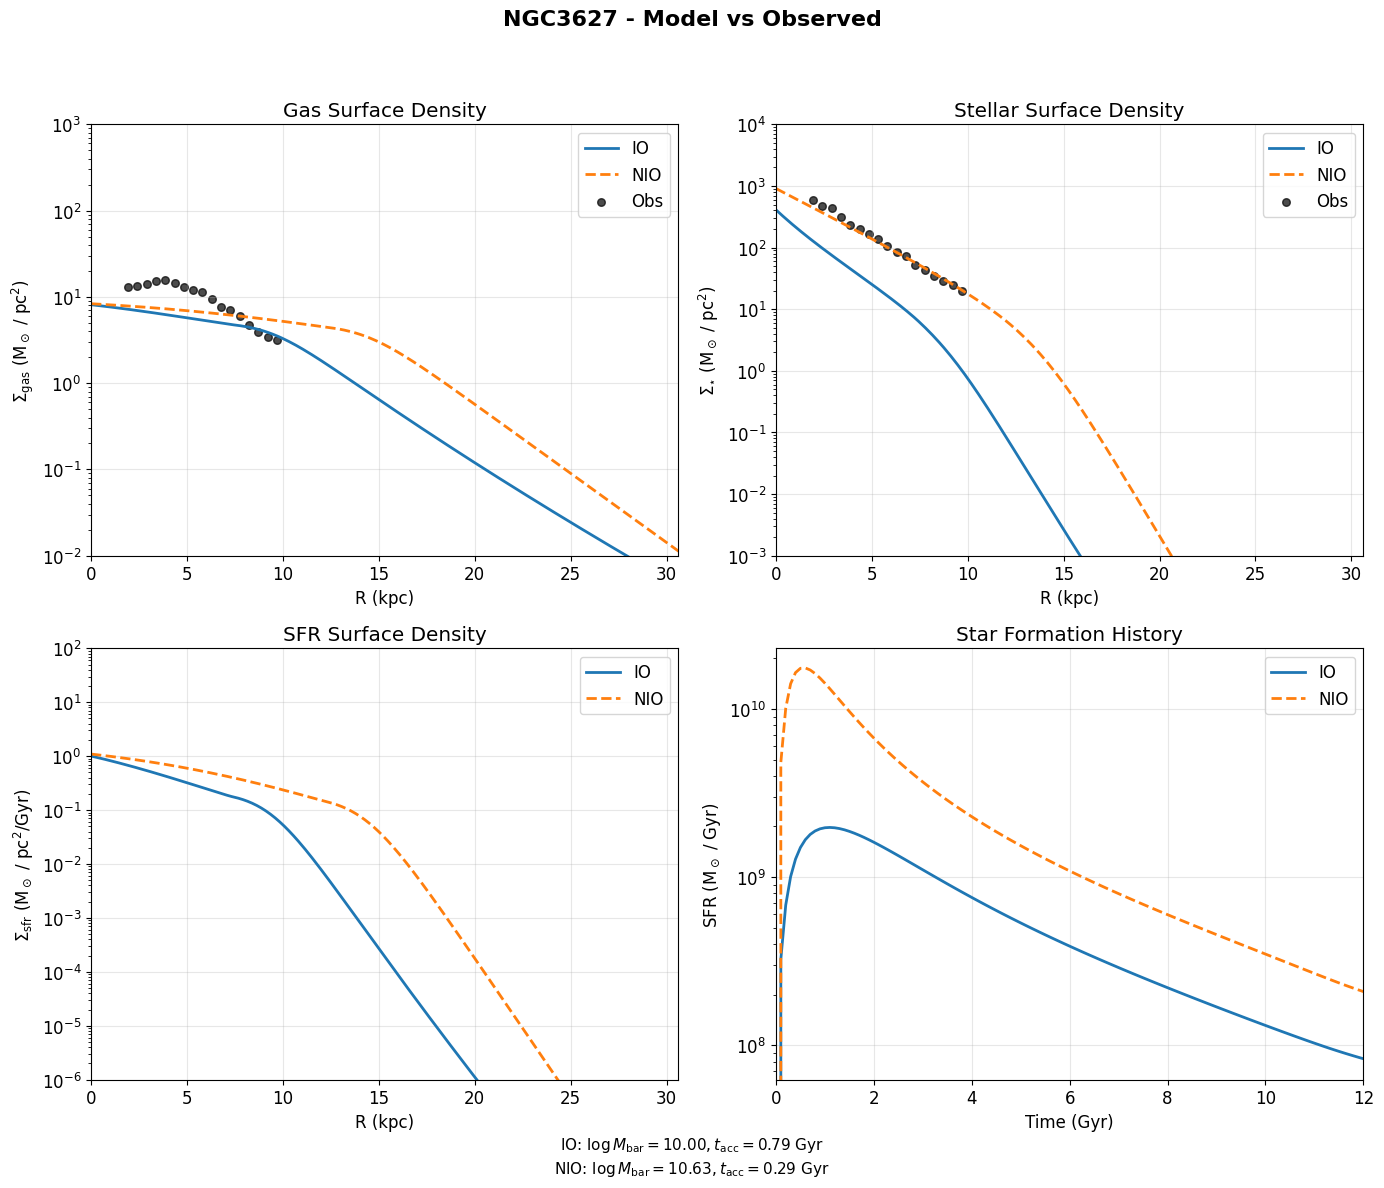

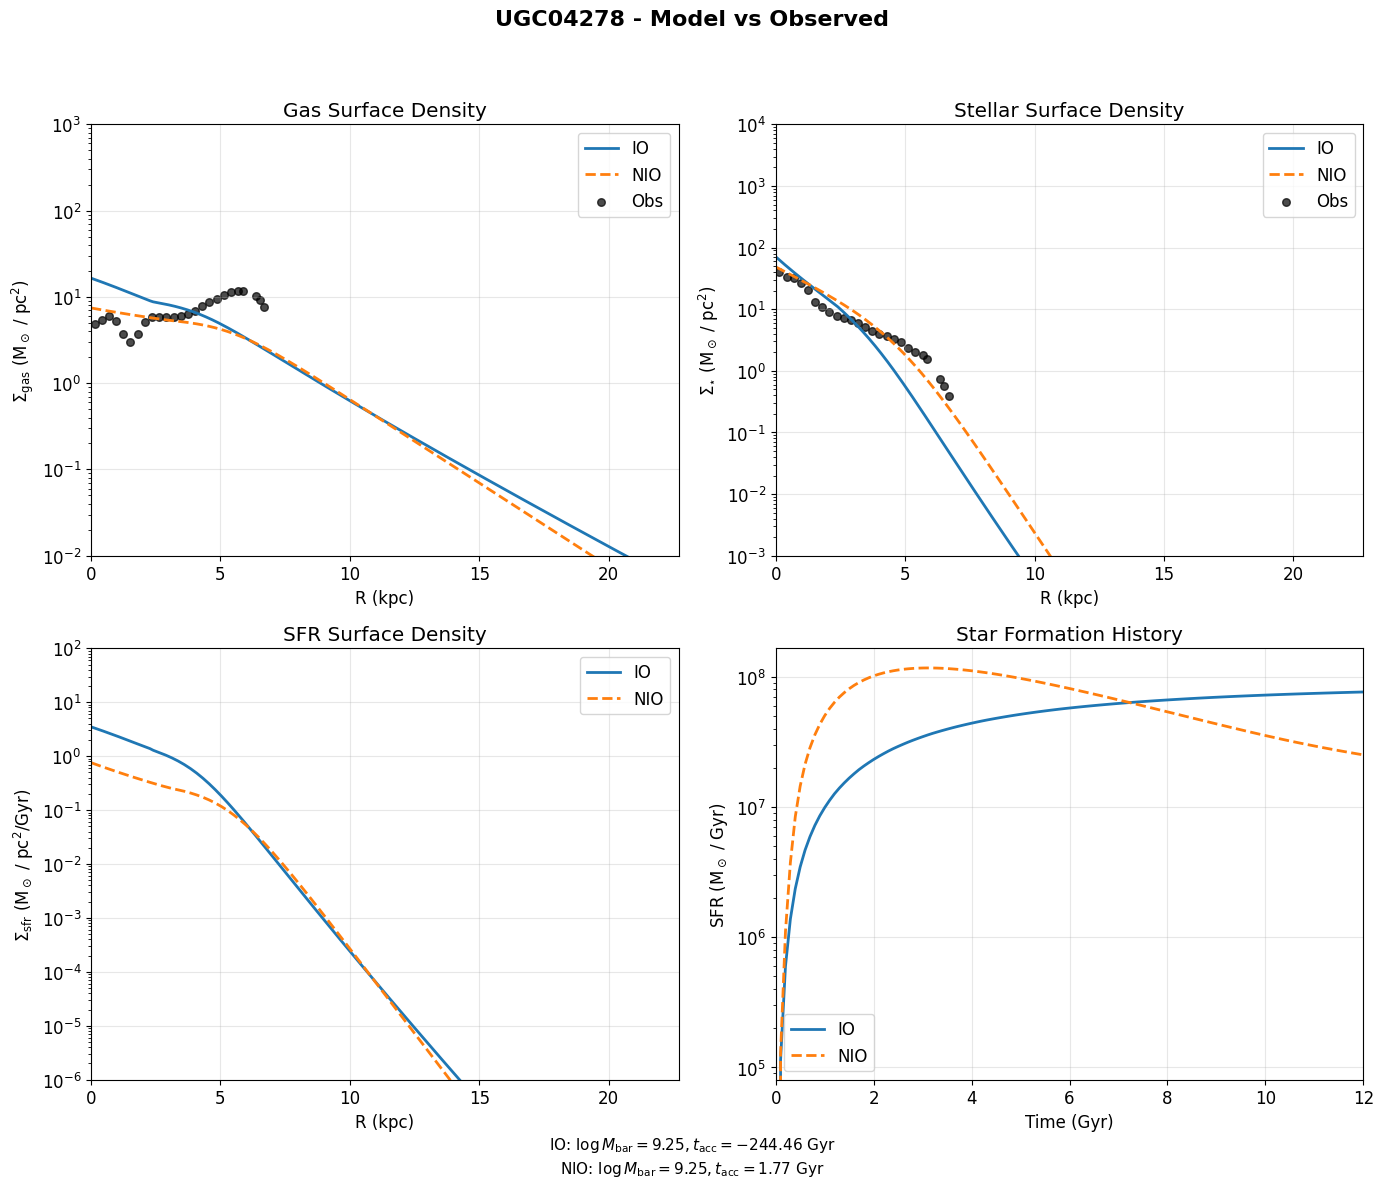

In [5]:
output_dir = BASE_DIR / "outputs" / "radial_profile_comparisons"
output_dir.mkdir(exist_ok=True, parents=True)

for gal in GALAXIES:
    fig = plot_galaxy_comparison(gal, profiles[gal])
    fig.savefig(output_dir / f"{gal}_profile_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## Time Evolution

In [6]:
def plot_time_evolution(gal, p, times_to_plot=[3, 6, 9, 12], x_max=None, model_type="io"):
    io = p["io"]
    nio = p.get("nio", None)
    if io is None and nio is None: return None

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
    fig.suptitle(f"{gal} - Time Evolution ({model_type.upper()})", fontsize=14, fontweight="bold")

    r_kpc, times = io["r_kpc"], io["times"]
    cmap = plt.cm.viridis

    for t_target in times_to_plot:
        t_idx = np.argmin(np.abs(times - t_target))
        color = cmap(t_target / 12.0)
        if model_type == "io":
            axes[0].plot(r_kpc, io["Sigma_gas"][:, t_idx], color=color, label=f"t={times[t_idx]:.1f}")
            axes[1].plot(r_kpc, io["Sigma_star"][:, t_idx], color=color)
            axes[2].plot(r_kpc, io["Sigma_sfr"][:, t_idx], color=color)
        elif model_type == "nio":
            axes[0].plot(r_kpc, nio["Sigma_gas"][:, t_idx], color=color, label=f"t={times[t_idx]:.1f}")
            axes[1].plot(r_kpc, nio["Sigma_star"][:, t_idx], color=color)
            axes[2].plot(r_kpc, nio["Sigma_sfr"][:, t_idx], color=color)
        else:
            raise ValueError("model_type must be 'io' or 'nio'")

    # Auto-determine x_max if not provided: find where gas density drops below threshold
    if x_max is None:
        final_gas = io["Sigma_gas"][:, -1]
        valid_idx = np.where(final_gas > 1e-2)[0]
        x_max = r_kpc[valid_idx[-1]] * 1.1 if len(valid_idx) > 0 else r_kpc[-1]

    for i, (ax, title, ylim) in enumerate(zip(axes, [r"$\Sigma_{\rm gas}$", r"$\Sigma_{\star}$", r"$\Sigma_{\rm sfr}$"], [(1e-2, 1e3), (1e-3, 1e4), (1e-6, 1e2)])):
        ax.set_xlabel("R (kpc)")
        ax.set_yscale("log")
        ax.set_xlim(0, x_max)
        ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=9)
    plt.tight_layout()
    return fig

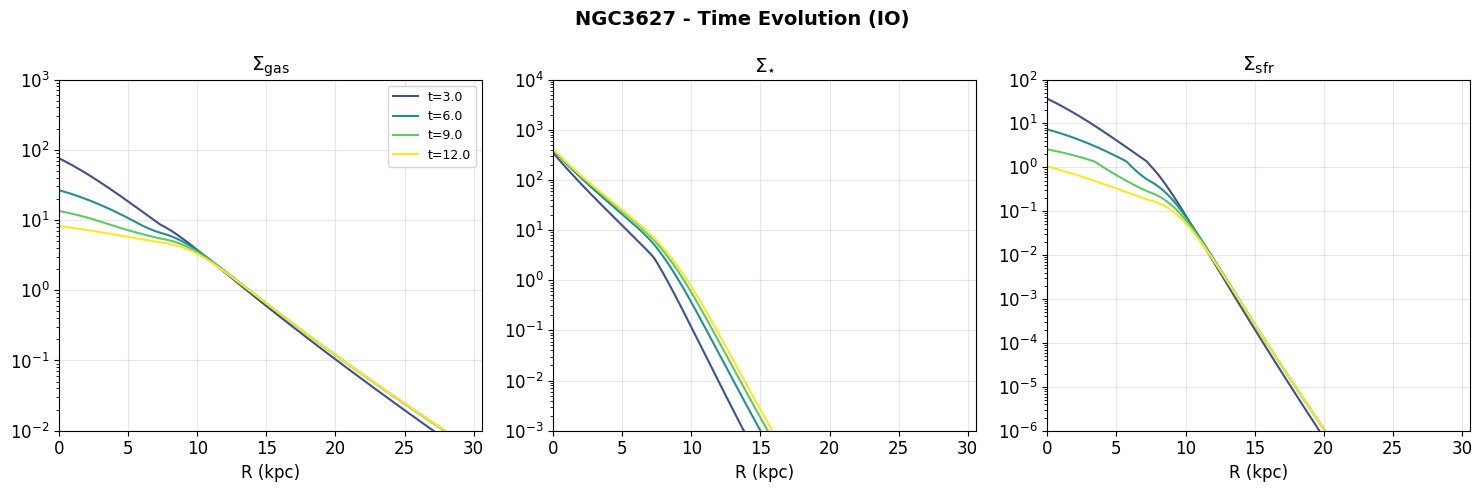

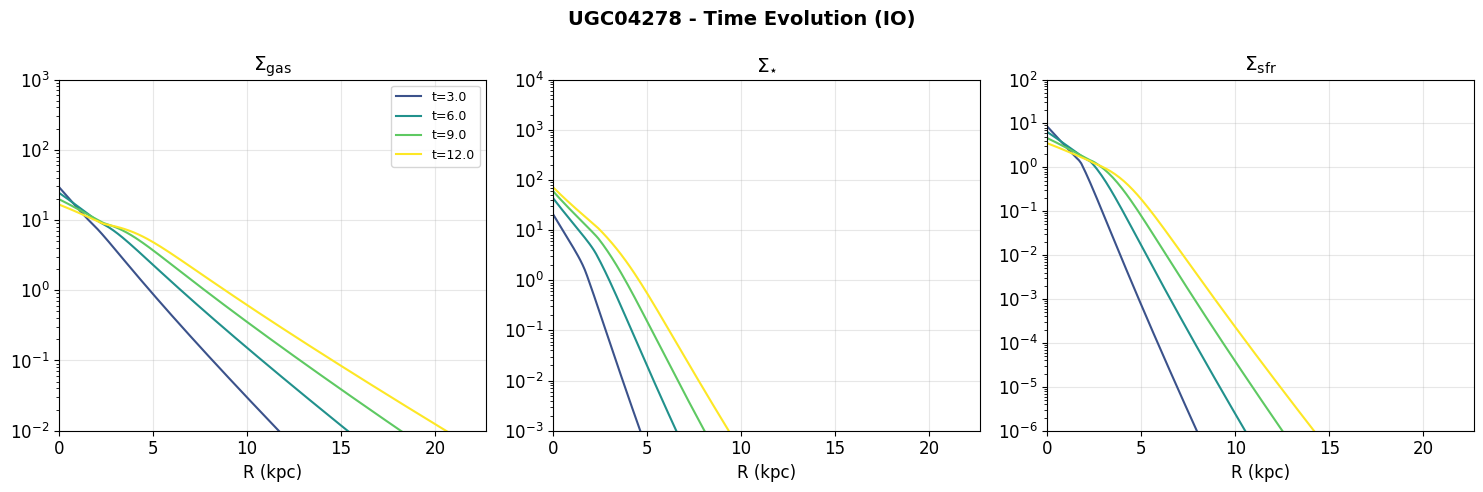

In [7]:
for gal in GALAXIES:
    fig = plot_time_evolution(gal, profiles[gal], model_type="io")
    if fig:
        fig.savefig(output_dir / f"{gal}_time_evolution_io.png", dpi=150, bbox_inches="tight")
        plt.show()

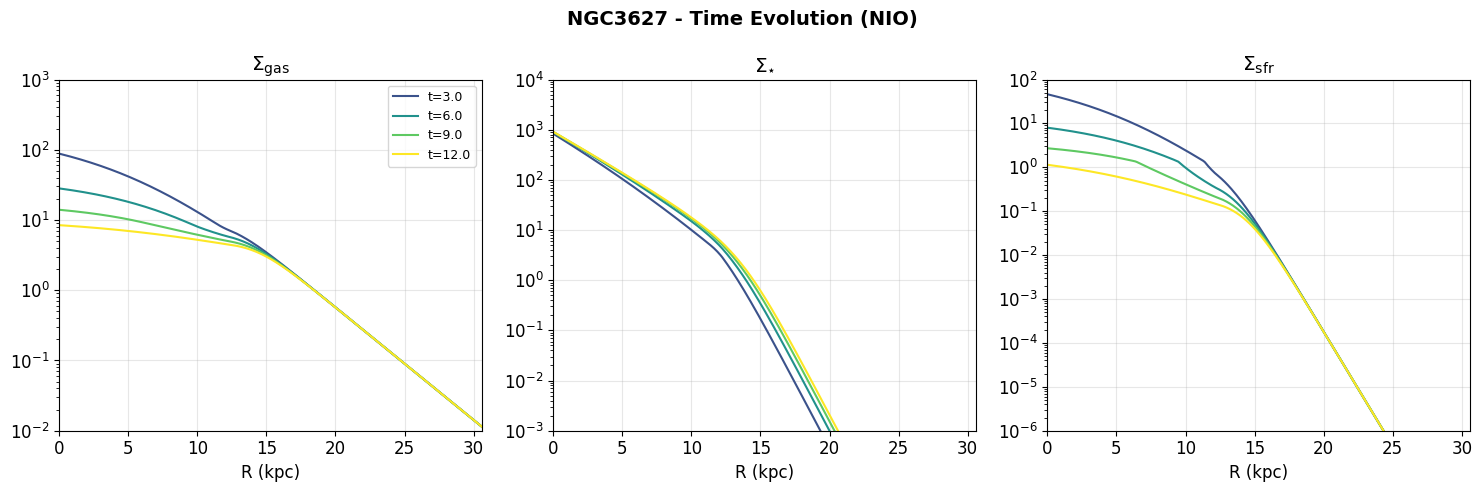

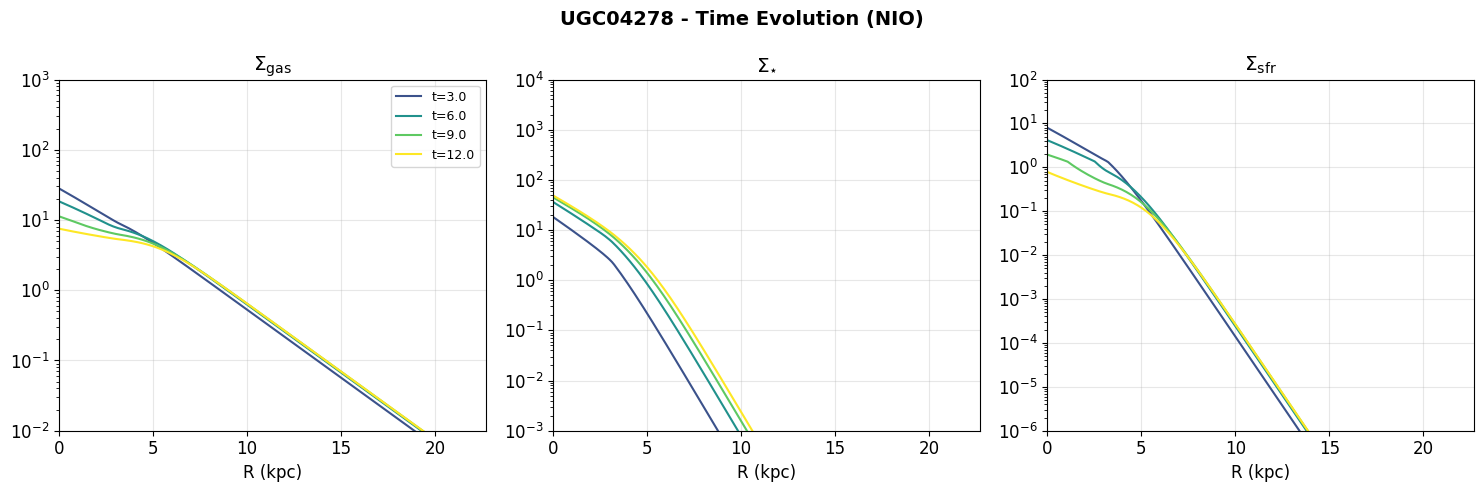

In [8]:
for gal in GALAXIES:
    fig = plot_time_evolution(gal, profiles[gal], model_type="nio")
    if fig:
        fig.savefig(output_dir / f"{gal}_time_evolution_nio.png", dpi=150, bbox_inches="tight")
        plt.show()

Loaded Dwarfs: 11 galaxies
Loaded Superthin: 5 galaxies
Loaded HIX: 12 galaxies
Loaded Superspirals: 38 galaxies

Loaded model profiles:
  logM=9: IO has 11 points, NIO has 10 points
  logM=10: IO has 11 points, NIO has 10 points
  logM=11: IO has 11 points, NIO has 10 points


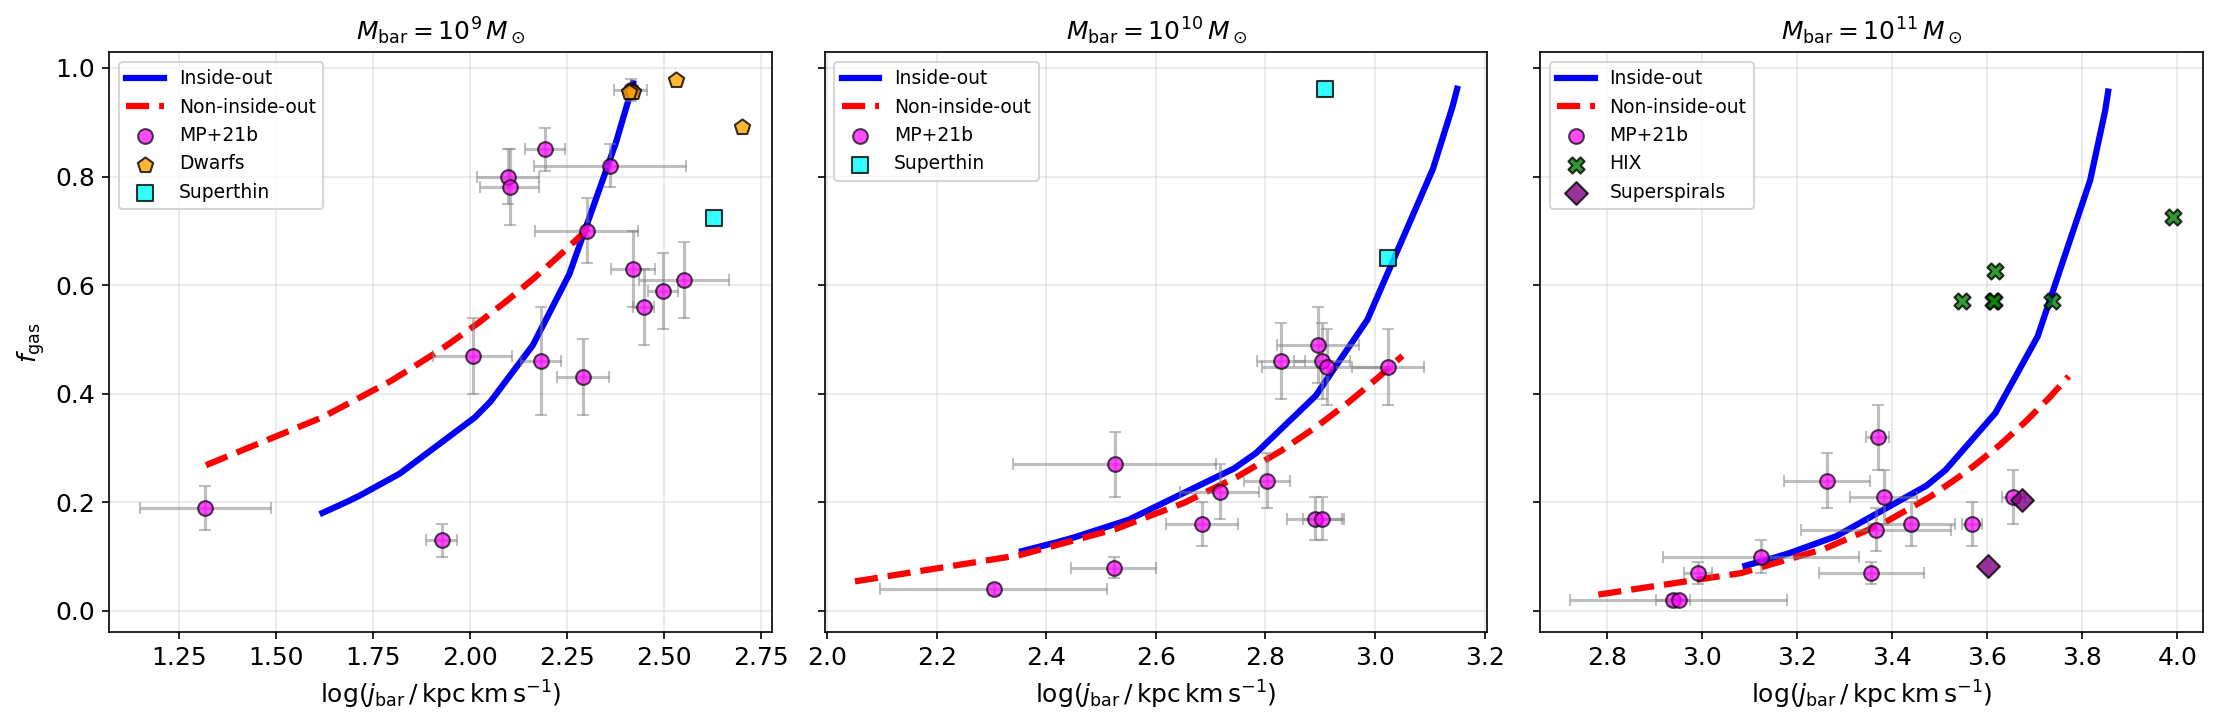

In [9]:
BARY_9 = pd.read_csv('../data/baryons_9.csv')
BARY_10 = pd.read_csv('../data/baryons_10.csv')
BARY_11 = pd.read_csv('../data/baryons_11.csv')

for df in [BARY_9, BARY_10, BARY_11]:
    df['j'] = pd.to_numeric(df['j'], errors='coerce')
    df['e_j'] = pd.to_numeric(df['e_j'], errors='coerce')
    df['fgas'] = pd.to_numeric(df['fgas'], errors='coerce')
    df['e_fgas'] = pd.to_numeric(df['e_fgas'], errors='coerce')

# Load all galaxy types from compilation_AM_others
galaxy_types = ['Dwarfs', 'Superthin', 'HIX', 'Superspirals'] #, 'UDGs', 'GLSBs'
marker_map = {
    'Dwarfs': 'p',
    'Superthin': 's',
    'HIX': 'X',
    'Superspirals': 'D',
    # 'UDGs': 'P',
    # 'GLSBs': '^'
}
color_map = {
    'Dwarfs': 'orange',
    'Superthin': 'cyan',
    'HIX': 'green',
    'Superspirals': 'purple',
    # 'UDGs': 'brown',
    # 'GLSBs': 'olive'
}

# Load all galaxy data
compilation_data = {}
for gtype in galaxy_types:
    df = pd.read_csv(f'../data/compilation_AM_others/{gtype}.csv')
    df['logMbar'] = pd.to_numeric(df['logMbar'], errors='coerce')
    df['logjbar'] = pd.to_numeric(df['logjbar'], errors='coerce')
    df['fgas'] = pd.to_numeric(df['fgas'], errors='coerce')
    compilation_data[gtype] = df
    print(f"Loaded {gtype}: {len(df)} galaxies")

# Load model profiles from saved CSV files
masses = [9, 10, 11]
io_profiles = {}
nio_profiles = {}

for logM in masses:
    # Inside-out model
    io_file = f'../outputs/jbar_fgas_profiles/io/jbar_fgas_logM{logM}.csv'
    io_df = pd.read_csv(io_file)
    io_profiles[logM] = {
        'j_bar': io_df['j_bar_kpc_km_s'].values,
        'f_gas': io_df['f_gas'].values
    }

    # Non-inside-out model
    nio_file = f'../outputs/jbar_fgas_profiles/nio/jbar_fgas_logM{logM}.csv'
    nio_df = pd.read_csv(nio_file)
    nio_profiles[logM] = {
        'j_bar': nio_df['j_bar_kpc_km_s'].values,
        'f_gas': nio_df['f_gas'].values
    }

print("\nLoaded model profiles:")
for logM in masses:
    print(f"  logM={logM}: IO has {len(io_profiles[logM]['j_bar'])} points, NIO has {len(nio_profiles[logM]['j_bar'])} points")

# Create mosaic plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150, sharey=True)

obs_data = {9: BARY_9, 10: BARY_10, 11: BARY_11}

for i, logM in enumerate(masses):
    ax = axes[i]

    # Inside-out model curve
    j_bar_io = io_profiles[logM]['j_bar']
    f_gas_io = io_profiles[logM]['f_gas']
    ax.plot(np.log10(j_bar_io), f_gas_io,
            color='blue', lw=3, label='Inside-out')

    # Non-inside-out model curve
    j_bar_nio = nio_profiles[logM]['j_bar']
    f_gas_nio = nio_profiles[logM]['f_gas']
    ax.plot(np.log10(j_bar_nio), f_gas_nio,
            color='red', lw=3, ls='--', label='Non-inside-out')

    # Observed data (MP+21b)
    df_obs = obs_data[logM]
    valid_obs = (df_obs['j'] > 0) & (df_obs['fgas'] > 0)
    obs_j = np.log10(df_obs.loc[valid_obs, 'j'].values)
    obs_f = df_obs.loc[valid_obs, 'fgas'].values
    obs_j_err = df_obs.loc[valid_obs, 'e_j'].values / df_obs.loc[valid_obs, 'j'].values / np.log(10)
    obs_f_err = df_obs.loc[valid_obs, 'e_fgas'].values

    ax.scatter(obs_j, obs_f, c='magenta', s=50, edgecolors='k',
               alpha=0.7, zorder=5, label='MP+21b')
    ax.errorbar(obs_j, obs_f, xerr=obs_j_err, yerr=obs_f_err,
                fmt=' ', ecolor='grey', capsize=3, alpha=0.5, zorder=4)

    # Add galaxies from compilation_AM_others within +/- 0.2 dex of target mass
    for gtype in galaxy_types:
        df = compilation_data[gtype]
        # Filter by mass range
        mask = (df['logMbar'] >= logM - 0.2) & (df['logMbar'] <= logM + 0.2)
        mask = mask & df['logjbar'].notna() & df['fgas'].notna()

        if mask.sum() > 0:
            gal_j = df.loc[mask, 'logjbar'].values
            gal_f = df.loc[mask, 'fgas'].values
            # Error: 13% relative error in j_bar
            gal_j_err = 0.13 / np.log(10)
            gal_f_err = 0.21 * gal_f

            ax.scatter(gal_j, gal_f, c=color_map[gtype], s=60, edgecolors='k',
                       alpha=0.8, zorder=6, marker=marker_map[gtype], label=gtype)
            # ax.errorbar(gal_j, gal_f, xerr=gal_j_err, yerr=gal_f_err,
            #             fmt=' ', ecolor='grey', capsize=3, alpha=0.5, zorder=4)

    ax.set_title(rf'$M_{{\rm bar}} = 10^{{{logM}}} \, M_\odot$', fontsize=12)
    ax.set_xlabel(r'$\log(j_{\rm bar} \, / \, {\rm kpc \, km \, s^{-1}})$', fontsize=12)
    if i == 0:
        ax.set_ylabel(r'$f_{\rm gas}$', fontsize=12)
    ax.grid(alpha=0.3)

    # Create legend with unique entries only
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/jbar_fgas_profiles/jbar_vs_fgas_mosaic_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
print("j_bar range comparison (in dex):\n")
print(f"{'logM':<6} {'IO range':<12} {'NIO range':<12} {'Difference':<12}")
print("-" * 45)

for logM in masses:
    # Inside-out
    io_df = pd.read_csv(f'../outputs/jbar_fgas_profiles/io/jbar_fgas_logM{logM}.csv')
    io_j = io_df['j_bar_kpc_km_s'].values
    io_range_dex = np.log10(io_j.max()) - np.log10(io_j.min())
    
    # Non-inside-out
    nio_df = pd.read_csv(f'../outputs/jbar_fgas_profiles/nio/jbar_fgas_logM{logM}.csv')
    nio_j = nio_df['j_bar_kpc_km_s'].values
    nio_range_dex = np.log10(nio_j.max()) - np.log10(nio_j.min())
    
    diff = nio_range_dex - io_range_dex
    
    print(f"{logM:<6} {io_range_dex:<12.3f} {nio_range_dex:<12.3f} {diff:<+12.3f}")

j_bar range comparison (in dex):

logM   IO range     NIO range    Difference  
---------------------------------------------
9      0.800        1.000        +0.200      
10     0.794        0.999        +0.205      
11     0.764        0.990        +0.226      


In [11]:
from scipy.interpolate import interp1d

def compute_chi2_vertical(model_j, model_f, obs_j, obs_f, obs_f_err):
    """
    Compute chi-squared using vertical (f_gas) residuals only.
    Interpolate model at observed j_bar values.
    """
    log_model_j = np.log10(model_j)
    
    # Only use points within model j range
    valid = (obs_j >= log_model_j.min()) & (obs_j <= log_model_j.max())
    if valid.sum() == 0:
        return np.nan, 0, np.zeros(len(obs_j), dtype=bool)
    
    interp_func = interp1d(log_model_j, model_f, kind='linear', bounds_error=False)
    model_at_obs = interp_func(obs_j[valid])
    
    residuals = obs_f[valid] - model_at_obs
    chi2 = np.sum((residuals / obs_f_err[valid])**2)
    
    return chi2, valid.sum(), valid

print("Chi-squared (vertical residuals in f_gas) comparison:\n")
print(f"{'logM':<6} {'IO χ²':<10} {'NIO χ²':<10} {'N':<6} {'IO χ²/N':<10} {'NIO χ²/N':<10} {'Better':<8}")
print("-" * 68)

for logM in masses:
    df_obs = obs_data[logM]
    valid_obs = (df_obs['j'] > 0) & (df_obs['fgas'] > 0)
    all_j = [np.log10(df_obs.loc[valid_obs, 'j'].values)]
    all_f = [df_obs.loc[valid_obs, 'fgas'].values]
    all_f_err = [df_obs.loc[valid_obs, 'e_fgas'].values]
    
    for gtype in galaxy_types:
        df = compilation_data[gtype]
        mask = (df['logMbar'] >= logM - 0.2) & (df['logMbar'] <= logM + 0.2) & df['logjbar'].notna() & df['fgas'].notna()
        if mask.sum() > 0:
            all_j.append(df.loc[mask, 'logjbar'].values)
            all_f.append(df.loc[mask, 'fgas'].values)
            all_f_err.append(0.21 * df.loc[mask, 'fgas'].values)
    
    obs_j = np.concatenate(all_j)
    obs_f = np.concatenate(all_f)
    obs_f_err = np.concatenate(all_f_err)
    
    # Get valid masks and use common points
    _, _, mask_io = compute_chi2_vertical(io_profiles[logM]['j_bar'], io_profiles[logM]['f_gas'], obs_j, obs_f, obs_f_err)
    _, _, mask_nio = compute_chi2_vertical(nio_profiles[logM]['j_bar'], nio_profiles[logM]['f_gas'], obs_j, obs_f, obs_f_err)
    common = mask_io & mask_nio
    
    chi2_io, n, _ = compute_chi2_vertical(io_profiles[logM]['j_bar'], io_profiles[logM]['f_gas'], 
                                           obs_j[common], obs_f[common], obs_f_err[common])
    chi2_nio, _, _ = compute_chi2_vertical(nio_profiles[logM]['j_bar'], nio_profiles[logM]['f_gas'], 
                                            obs_j[common], obs_f[common], obs_f_err[common])
    
    red_io = chi2_io / n if n > 0 else np.nan
    red_nio = chi2_nio / n if n > 0 else np.nan
    better = "IO" if chi2_io < chi2_nio else "NIO"
    
    print(f"{logM:<6} {chi2_io:<10.1f} {chi2_nio:<10.1f} {n:<6} {red_io:<10.2f} {red_nio:<10.2f} {better:<8}")

Chi-squared (vertical residuals in f_gas) comparison:

logM   IO χ²      NIO χ²     N      IO χ²/N    NIO χ²/N   Better  
--------------------------------------------------------------------
9      195.3      214.6      8      24.41      26.83      IO      
10     112.7      82.2       14     8.05       5.87       NIO     
11     354.9      219.0      16     22.18      13.69      NIO     


/var/folders/hz/s07cwl6d5_v5tr1l0jp_v5dr0000gn/T/ipykernel_59627/1348901078.py:19: RuntimeWarning: divide by zero encountered in divide
  chi2 = np.sum((residuals / obs_f_err[valid])**2)


In [12]:
print("Individual point comparison for logM=11:\n")
print(f"{'j_obs':<8} {'f_obs':<8} {'f_IO':<8} {'f_NIO':<8} {'res_IO':<10} {'res_NIO':<10} {'Better':<8}")
print("-" * 70)

logM = 11
df_obs = obs_data[logM]
valid_obs = (df_obs['j'] > 0) & (df_obs['fgas'] > 0)
all_j = [np.log10(df_obs.loc[valid_obs, 'j'].values)]
all_f = [df_obs.loc[valid_obs, 'fgas'].values]
all_f_err = [df_obs.loc[valid_obs, 'e_fgas'].values]
all_type = ['MP+21b'] * valid_obs.sum()

for gtype in galaxy_types:
    df = compilation_data[gtype]
    mask = (df['logMbar'] >= logM - 0.2) & (df['logMbar'] <= logM + 0.2) & df['logjbar'].notna() & df['fgas'].notna()
    if mask.sum() > 0:
        all_j.append(df.loc[mask, 'logjbar'].values)
        all_f.append(df.loc[mask, 'fgas'].values)
        all_f_err.append(0.21 * df.loc[mask, 'fgas'].values)
        all_type.extend([gtype] * mask.sum())

obs_j = np.concatenate(all_j)
obs_f = np.concatenate(all_f)
obs_f_err = np.concatenate(all_f_err)

# Interpolators
log_j_io = np.log10(io_profiles[logM]['j_bar'])
log_j_nio = np.log10(nio_profiles[logM]['j_bar'])
interp_io = interp1d(log_j_io, io_profiles[logM]['f_gas'], bounds_error=False, fill_value=np.nan)
interp_nio = interp1d(log_j_nio, nio_profiles[logM]['f_gas'], bounds_error=False, fill_value=np.nan)

sum_io, sum_nio = 0, 0
for i in range(len(obs_j)):
    f_io = interp_io(obs_j[i])
    f_nio = interp_nio(obs_j[i])
    
    if np.isnan(f_io) or np.isnan(f_nio):
        continue
    
    res_io = (obs_f[i] - f_io)**2 / obs_f_err[i]**2
    res_nio = (obs_f[i] - f_nio)**2 / obs_f_err[i]**2
    sum_io += res_io
    sum_nio += res_nio
    better = "IO" if res_io < res_nio else "NIO"
    
    print(f"{obs_j[i]:<8.2f} {obs_f[i]:<8.2f} {f_io:<8.2f} {f_nio:<8.2f} {res_io:<10.1f} {res_nio:<10.1f} {better:<8} ({all_type[i]})")

print(f"\nTotal: IO={sum_io:.1f}, NIO={sum_nio:.1f}")


Individual point comparison for logM=11:

j_obs    f_obs    f_IO     f_NIO    res_IO     res_NIO    Better  
----------------------------------------------------------------------
3.44     0.16     0.22     0.19     1.9        0.6        NIO      (MP+21b)
3.57     0.16     0.32     0.26     15.0       6.8        NIO      (MP+21b)
3.38     0.21     0.19     0.16     0.2        0.9        IO       (MP+21b)
3.65     0.21     0.42     0.33     18.4       5.6        NIO      (MP+21b)
3.37     0.32     0.18     0.16     5.4        7.4        IO       (MP+21b)
3.26     0.24     0.13     0.12     4.7        6.1        IO       (MP+21b)
3.36     0.07     0.17     0.15     27.0       16.8       NIO      (MP+21b)
3.36     0.15     0.18     0.16     0.5        0.0        NIO      (MP+21b)
3.12     0.10     0.09     0.08     0.1        0.4        IO       (MP+21b)
3.62     0.63     0.36     0.30     4.0        6.2        IO       (HIX)
3.55     0.57     0.29     0.25     5.3        7.1        IO   

## IO vs NIO Comparison Figures: Assumptions vs Results

Two figures comparing the inside-out (IO) and non-inside-out (NIO) models.
Each has 2 panels: left = "assumptions" (M_acc and j_acc), right = "results" (j_bar and f_gas).
Both use M_bar(t_0) = 10^10 Msun.

In [13]:
# Load comparison profiles
nio_high = np.load('../outputs/model_radial_profiles/nio/comparison_nio_high_jacc.npz', allow_pickle=True)
nio_low  = np.load('../outputs/model_radial_profiles/nio/comparison_nio_low_jacc.npz', allow_pickle=True)
io_pos   = np.load('../outputs/model_radial_profiles/io/comparison_io_pos_omega.npz', allow_pickle=True)
io_neg   = np.load('../outputs/model_radial_profiles/io/comparison_io_neg_omega.npz', allow_pickle=True)

print('NIO high j_acc:', {k: nio_high[k].shape if hasattr(nio_high[k], 'shape') else nio_high[k] for k in ['omega', 'C', 'j_acc_value', 'M_bar']})
print('NIO low  j_acc:', {k: nio_low[k].shape if hasattr(nio_low[k], 'shape') else nio_low[k] for k in ['omega', 'C', 'j_acc_value', 'M_bar']})
print('IO  pos omega: ', {k: io_pos[k].shape if hasattr(io_pos[k], 'shape') else io_pos[k] for k in ['omega', 'C', 'M_bar', 'k', 'n']})
print('IO  neg omega: ', {k: io_neg[k].shape if hasattr(io_neg[k], 'shape') else io_neg[k] for k in ['omega', 'C', 'M_bar', 'k', 'n']})

NIO high j_acc: {'omega': (), 'C': (), 'j_acc_value': (), 'M_bar': ()}
NIO low  j_acc: {'omega': (), 'C': (), 'j_acc_value': (), 'M_bar': ()}
IO  pos omega:  {'omega': (), 'C': (), 'M_bar': (), 'k': (), 'n': ()}
IO  neg omega:  {'omega': (), 'C': (), 'M_bar': (), 'k': (), 'n': ()}


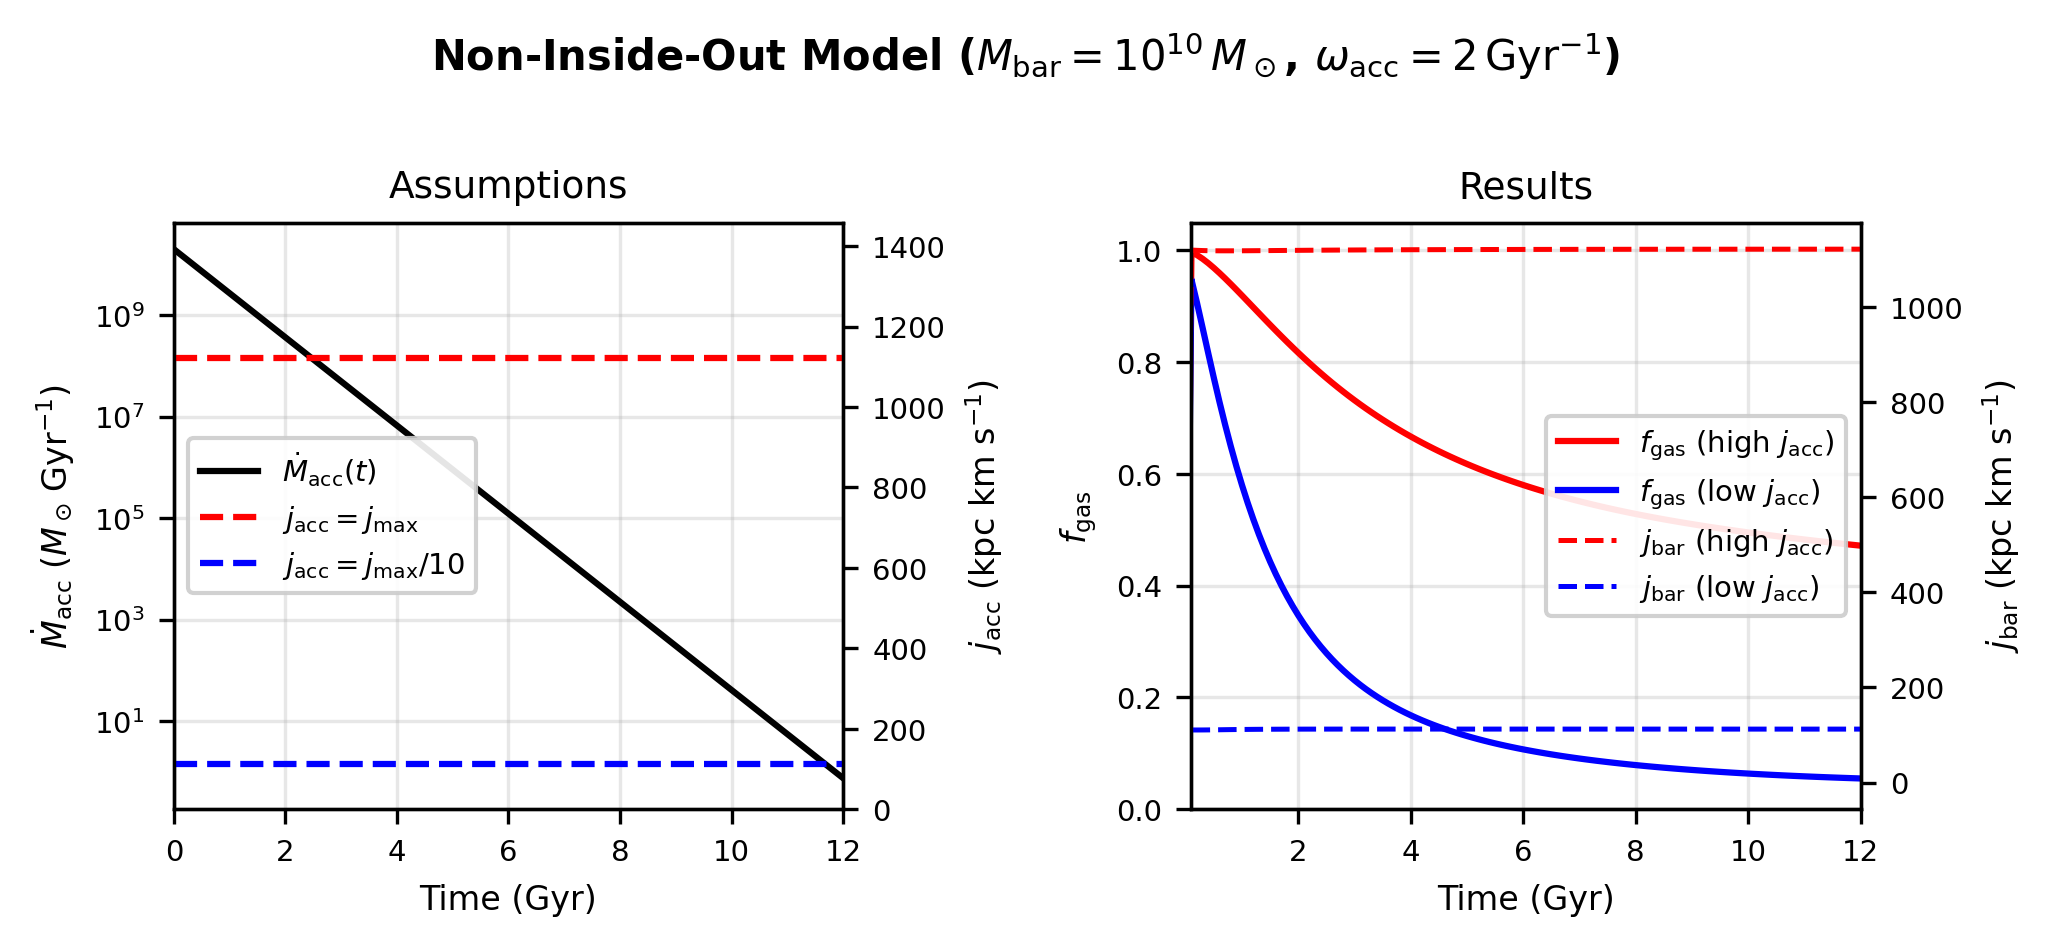

In [64]:
# Figure 1: NIO model — Assumptions vs Results

times = nio_high['times']
omega = float(nio_high['omega'])
C_nio = float(nio_high['C'])
j_high = float(nio_high['j_acc_value'])
j_low = float(nio_low['j_acc_value'])

# M_dot_acc(t) = C * exp(-omega * t)
M_dot_acc = C_nio * np.exp(-omega * times)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(7, 3.2), dpi=300)

# --- Left panel: Assumptions ---
ax_left.set_title('Assumptions', fontsize=9)
ax_left.plot(times, M_dot_acc, 'k-', lw=1.5,
             label=rf'$\dot{{M}}_{{\rm acc}}(t)$')
ax_left.set_xlabel('Time (Gyr)', fontsize=8)
ax_left.set_ylabel(r'$\dot{M}_{\rm acc}$ ($M_\odot\,{\rm Gyr}^{-1}$)', fontsize=8)
ax_left.set_xlim(0, 12)
ax_left.set_yscale('log')
ax_left.tick_params(axis='both', labelsize=7)
ax_left.grid(True, alpha=0.3)

# Right y-axis for j_acc
ax_j = ax_left.twinx()
ax_j.axhline(j_high, color='red', ls='--', lw=1.5,
             label=rf'$j_{{\rm acc}} = j_{{\rm max}}$')
ax_j.axhline(j_low, color='blue', ls='--', lw=1.5,
             label=rf'$j_{{\rm acc}} = j_{{\rm max}}/10$')
ax_j.set_ylabel(r'$j_{\rm acc}$ (kpc km s$^{-1}$)', fontsize=8)
ax_j.set_ylim(0, j_high * 1.3)
ax_j.tick_params(axis='y', labelsize=7)

# Combined legend
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_j.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2,
               loc='center left', fontsize=7, framealpha=0.9)

# --- Right panel: Results ---
ax_right.set_title('Results', fontsize=9)

# f_gas on left y-axis
ax_right.plot(times, nio_high['f_gas_t'], 'r-', lw=1.5,
              label=rf'$f_{{\rm gas}}$ (high $j_{{\rm acc}}$)')
ax_right.plot(times, nio_low['f_gas_t'], 'b-', lw=1.5,
              label=rf'$f_{{\rm gas}}$ (low $j_{{\rm acc}}$)')
ax_right.set_xlabel('Time (Gyr)', fontsize=8)
ax_right.set_ylabel(r'$f_{\rm gas}$', fontsize=8)
ax_right.set_xlim(0.1, 12)
ax_right.set_ylim(0, 1.05)
ax_right.tick_params(axis='both', labelsize=7)
ax_right.grid(True, alpha=0.3)

# j_bar on right y-axis
ax_jbar = ax_right.twinx()
ax_jbar.plot(times, nio_high['j_bar_t'], 'r--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ (high $j_{{\rm acc}}$)')
ax_jbar.plot(times, nio_low['j_bar_t'], 'b--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ (low $j_{{\rm acc}}$)')
ax_jbar.set_ylabel(r'$j_{\rm bar}$ (kpc km s$^{-1}$)', fontsize=8)
ax_jbar.tick_params(axis='y', labelsize=7)

# Combined legend
lines1, labels1 = ax_right.get_legend_handles_labels()
lines2, labels2 = ax_jbar.get_legend_handles_labels()
ax_right.legend(lines1 + lines2, labels1 + labels2,
                loc='center right', fontsize=7, framealpha=0.9)

fig.suptitle(rf'Non-Inside-Out Model ($M_{{\rm bar}} = 10^{{10}}\,M_\odot$, $\omega_{{\rm acc}} = {omega:.0f}\,{{\rm Gyr}}^{{-1}}$)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
fig.savefig(output_dir / 'comparison_nio_assumptions_vs_results.pdf',
            bbox_inches='tight')
plt.show()

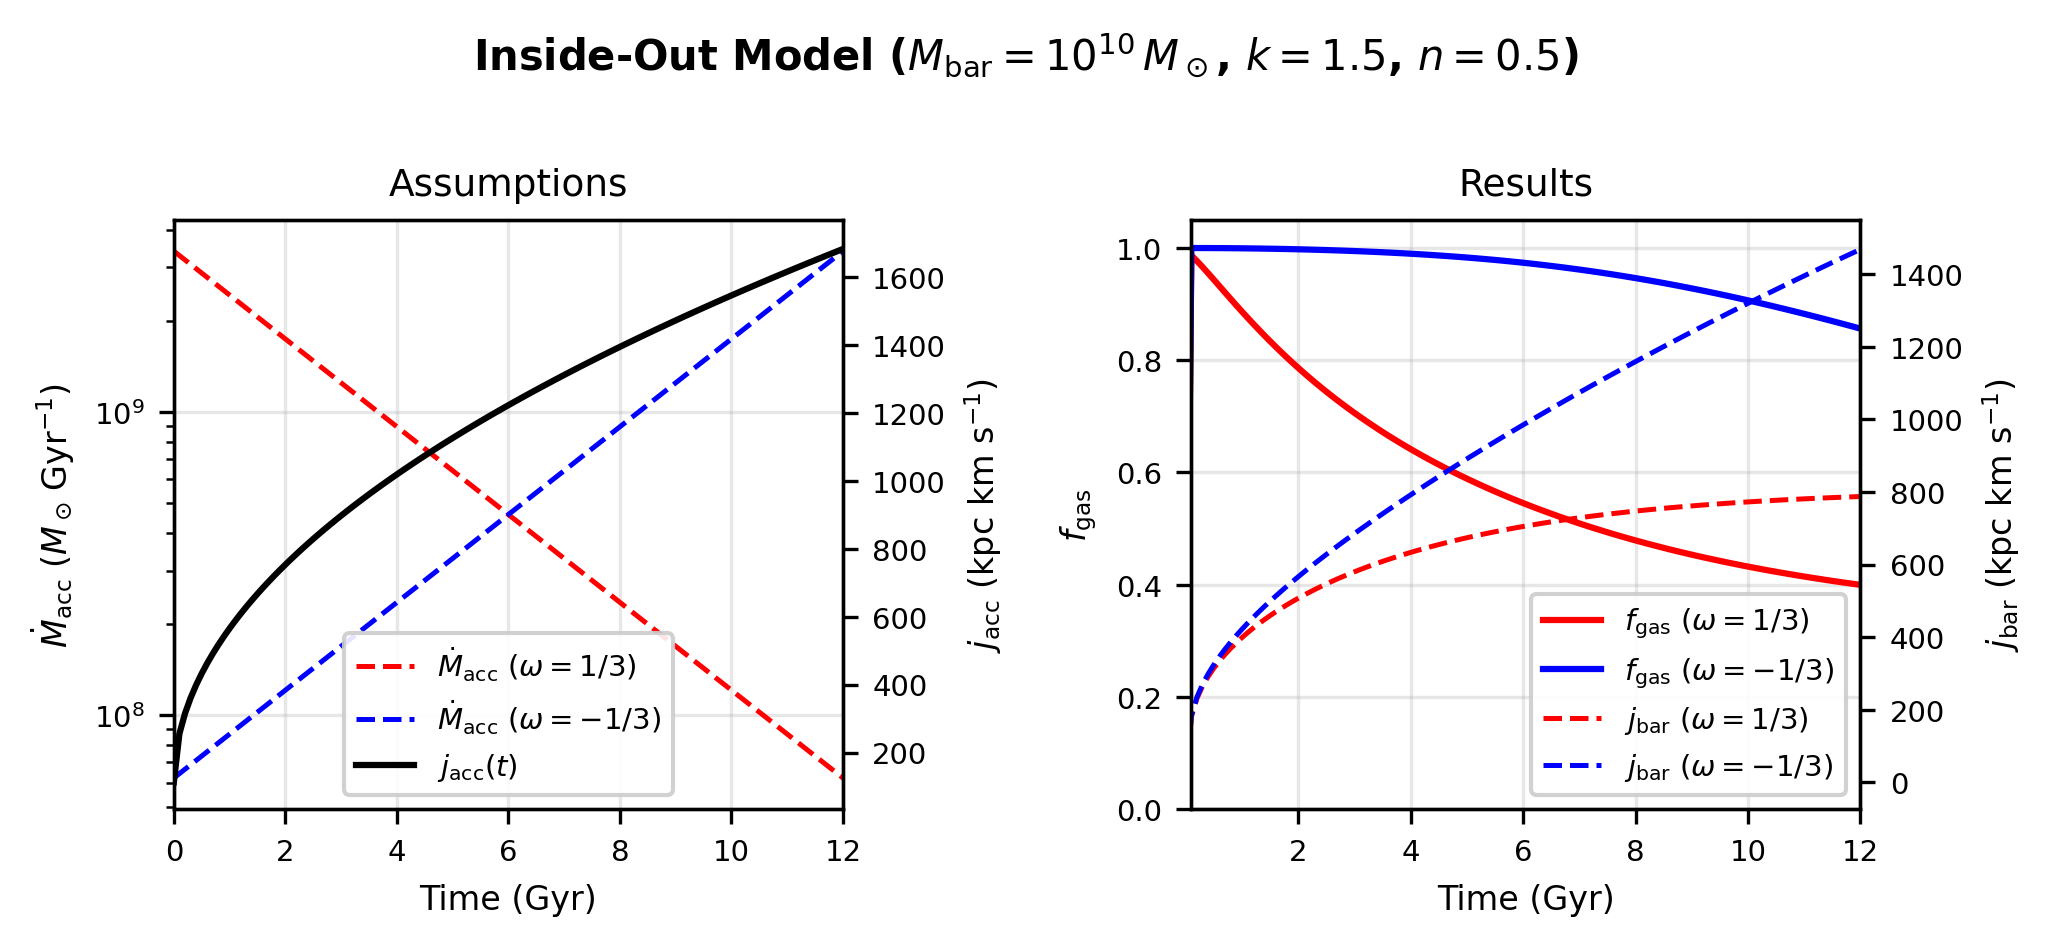

In [ ]:
# Figure 2: IO model — Assumptions vs Results

times_io = io_pos['times']
j_acc_t = io_pos['j_acc_t']

omega_p = float(io_pos['omega'])
omega_n = float(io_neg['omega'])
C_pos = float(io_pos['C'])
C_neg = float(io_neg['C'])

# M_dot_acc(t) = C * exp(-omega * t)
M_dot_pos = C_pos * np.exp(-omega_p * times_io)
M_dot_neg = C_neg * np.exp(-omega_n * times_io)

# Fraction labels
frac_p = Fraction(omega_p).limit_denominator(10)
frac_n = Fraction(omega_n).limit_denominator(10)
lbl_p = rf'{frac_p.numerator}/{frac_p.denominator}'
lbl_n = rf'{frac_n.numerator}/{frac_n.denominator}'

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(7, 3.2), dpi=300)

# --- Left panel: Assumptions ---
ax_left.set_title('Assumptions', fontsize=9)

# j_acc(t) on left y-axis — black solid
ax_left.plot(times_io, M_dot_pos, 'r--', lw=1.2,
          label=rf'$\dot{{M}}_{{\rm acc}}$ ($\omega={lbl_p}$)')
ax_left.plot(times_io, M_dot_neg, 'b--', lw=1.2,
          label=rf'$\dot{{M}}_{{\rm acc}}$ ($\omega={lbl_n}$)')

ax_left.set_xlabel('Time (Gyr)', fontsize=8)
ax_left.set_ylabel(r'$\dot{M}_{\rm acc}$ ($M_\odot\,{\rm Gyr}^{-1}$)', fontsize=8)
ax_left.set_xlim(0, 12)
ax_left.set_yscale('log')
ax_left.tick_params(axis='both', labelsize=7)
ax_left.grid(True, alpha=0.3)

# M_dot_acc on right y-axis
ax_m = ax_left.twinx()
ax_m.plot(times_io, j_acc_t, 'k-', lw=1.5, label=r'$j_{\rm acc}(t)$')
ax_m.set_ylabel(r'$j_{\rm acc}$ (kpc km s$^{-1}$)', fontsize=8)
ax_m.tick_params(axis='y', labelsize=7)

# Combined legend
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_m.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2,
               loc='lower center', fontsize=7, framealpha=0.9)

# --- Right panel: Results ---
ax_right.set_title('Results', fontsize=9)

# f_gas on left y-axis
ax_right.plot(times_io, io_pos['f_gas_t'], 'b-', lw=1.5,
              label=rf'$f_{{\rm gas}}$ ($\omega={lbl_p}$)')
ax_right.plot(times_io, io_neg['f_gas_t'], 'r-', lw=1.5,
              label=rf'$f_{{\rm gas}}$ ($\omega={lbl_n}$)')
ax_right.set_xlabel('Time (Gyr)', fontsize=8)
ax_right.set_ylabel(r'$f_{\rm gas}$', fontsize=8)
ax_right.set_xlim(0.1, 12)
ax_right.set_ylim(0, 1.05)
ax_right.tick_params(axis='both', labelsize=7)
ax_right.grid(True, alpha=0.3)

# j_bar on right y-axis
ax_jbar = ax_right.twinx()
ax_jbar.plot(times_io, io_pos['j_bar_t'], 'b--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ ($\omega={lbl_p}$)')
ax_jbar.plot(times_io, io_neg['j_bar_t'], 'r--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ ($\omega={lbl_n}$)')
ax_jbar.set_ylabel(r'$j_{\rm bar}$ (kpc km s$^{-1}$)', fontsize=8)
ax_jbar.tick_params(axis='y', labelsize=7)

# Combined legend
lines1, labels1 = ax_right.get_legend_handles_labels()
lines2, labels2 = ax_jbar.get_legend_handles_labels()
ax_right.legend(lines1 + lines2, labels1 + labels2,
                loc='lower right', fontsize=7, framealpha=0.9)

fig.suptitle(r'Inside-Out Model ($M_{\rm bar} = 10^{10}\,M_\odot$, $k=1.5$, $n=0.5$)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
fig.savefig(output_dir / 'comparison_io_assumptions_vs_results.pdf',
            bbox_inches='tight')
plt.show()

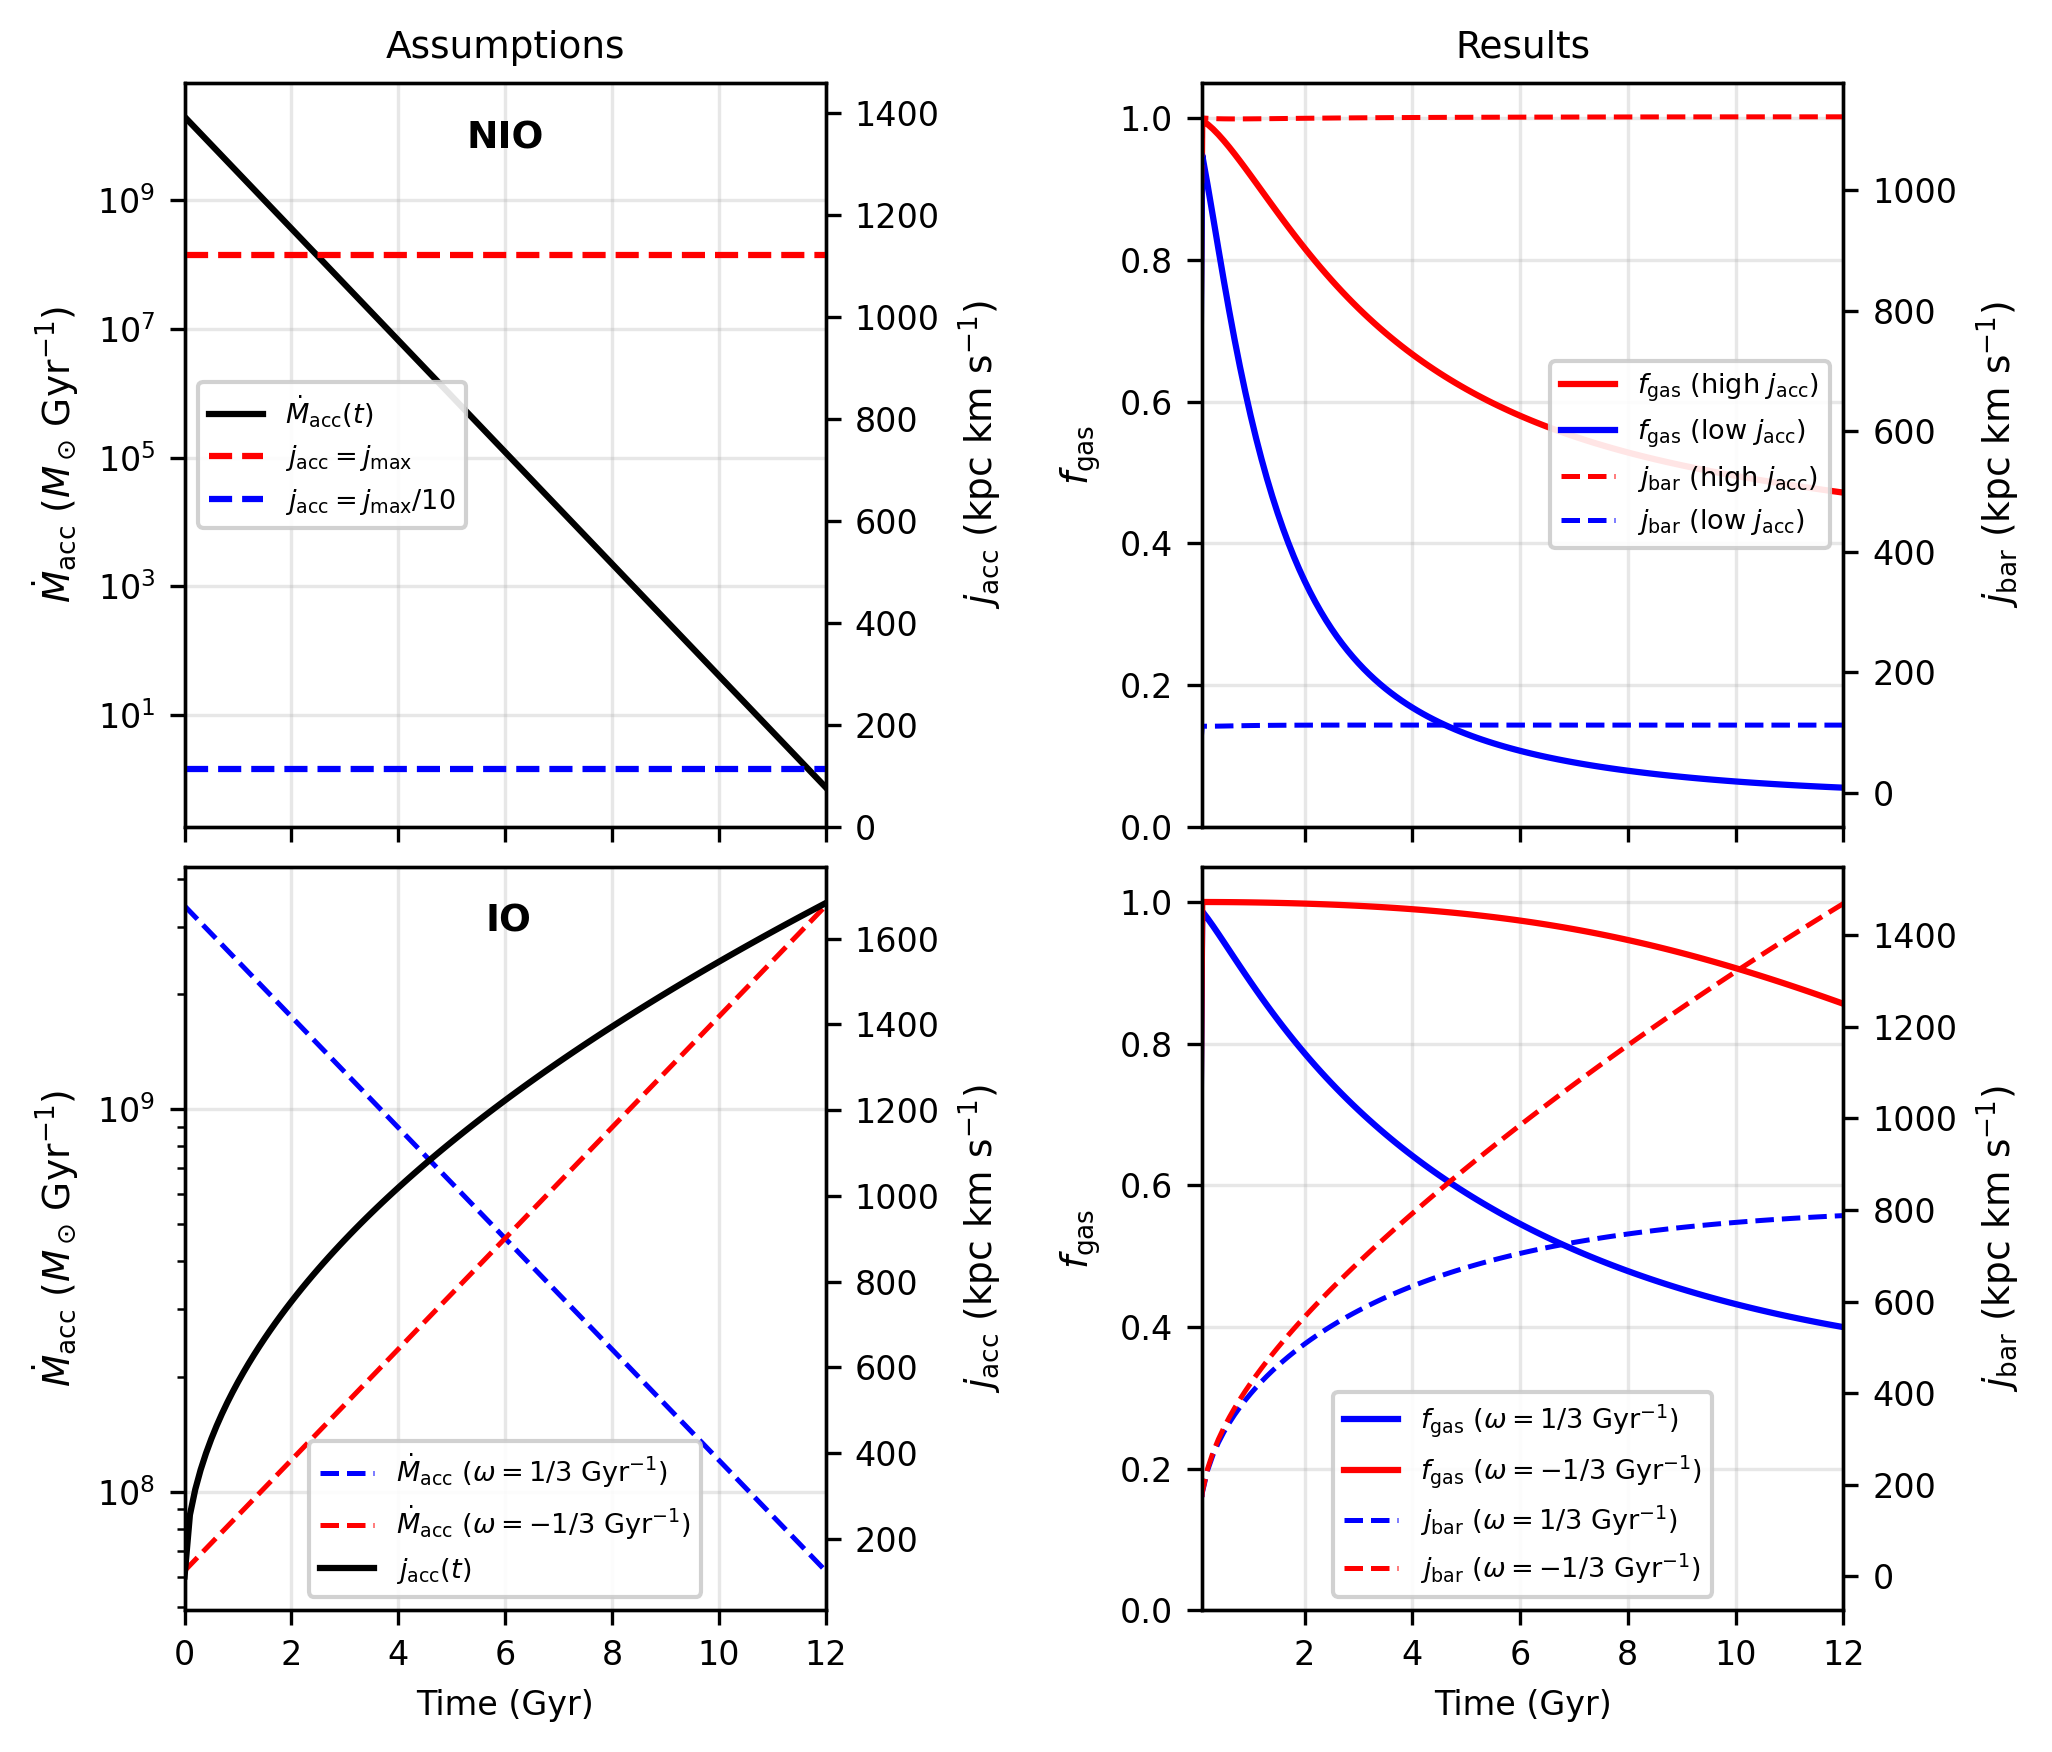

In [83]:
# Combined 2x2 figure: top row = NIO, bottom row = IO

fig, axes = plt.subplots(2, 2, figsize=(7, 6), dpi=300)

# ============================================================
# Top row: NIO model
# ============================================================
times_nio = nio_high['times']
omega_nio = float(nio_high['omega'])
C_nio = float(nio_high['C'])
j_high = float(nio_high['j_acc_value'])
j_low = float(nio_low['j_acc_value'])
M_dot_nio = C_nio * np.exp(-omega_nio * times_nio)

# Top-left: NIO Assumptions
ax = axes[0, 0]
ax.plot(times_nio, M_dot_nio, 'k-', lw=1.5,
        label=r'$\dot{M}_{\rm acc}(t)$')
ax.set_ylabel(r'$\dot{M}_{\rm acc}$ ($M_\odot\,{\rm Gyr}^{-1}$)', fontsize=9)
ax.set_yscale('log')
ax.set_xlim(0, 12)
ax.tick_params(axis='both', labelsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.44, 0.95, 'NIO', transform=ax.transAxes, fontsize=9,
        fontweight='bold', va='top')

ax_j = ax.twinx()
ax_j.axhline(j_high, color='red', ls='--', lw=1.5,
             label=r'$j_{\rm acc} = j_{\rm max}$')
ax_j.axhline(j_low, color='blue', ls='--', lw=1.5,
             label=r'$j_{\rm acc} = j_{\rm max}/10$')
ax_j.set_ylabel(r'$j_{\rm acc}$ (kpc km s$^{-1}$)', fontsize=9)
ax_j.set_ylim(0, j_high * 1.3)
ax_j.tick_params(axis='y', labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_j.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='center left', fontsize=6.5, framealpha=0.9)

# Top-right: NIO Results
ax = axes[0, 1]
ax.plot(times_nio, nio_high['f_gas_t'], 'r-', lw=1.5,
        label=r'$f_{\rm gas}$ (high $j_{\rm acc}$)')
ax.plot(times_nio, nio_low['f_gas_t'], 'b-', lw=1.5,
        label=r'$f_{\rm gas}$ (low $j_{\rm acc}$)')
ax.set_ylabel(r'$f_{\rm gas}$', fontsize=9)
ax.set_xlim(0.1, 12)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', labelsize=8)
ax.grid(True, alpha=0.3)

ax_jbar = ax.twinx()
ax_jbar.plot(times_nio, nio_high['j_bar_t'], 'r--', lw=1.2,
             label=r'$j_{\rm bar}$ (high $j_{\rm acc}$)')
ax_jbar.plot(times_nio, nio_low['j_bar_t'], 'b--', lw=1.2,
             label=r'$j_{\rm bar}$ (low $j_{\rm acc}$)')
ax_jbar.set_ylabel(r'$j_{\rm bar}$ (kpc km s$^{-1}$)', fontsize=9)
ax_jbar.tick_params(axis='y', labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_jbar.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='center right', fontsize=6.5, framealpha=0.9)

# ============================================================
# Bottom row: IO model
# ============================================================
times_io = io_pos['times']
j_acc_t = io_pos['j_acc_t']
omega_p = float(io_pos['omega'])
omega_n = float(io_neg['omega'])
C_p = float(io_pos['C'])
C_n = float(io_neg['C'])
M_dot_pos = C_p * np.exp(-omega_p * times_io)
M_dot_neg = C_n * np.exp(-omega_n * times_io)

frac_p = Fraction(omega_p).limit_denominator(10)
frac_n = Fraction(omega_n).limit_denominator(10)
lbl_p = rf'{frac_p.numerator}/{frac_p.denominator}'
lbl_n = rf'{frac_n.numerator}/{frac_n.denominator}'

# Bottom-left: IO Assumptions
ax = axes[1, 0]
ax.plot(times_io, M_dot_pos, 'b--', lw=1.2,
        label=rf'$\dot{{M}}_{{\rm acc}}$ ($\omega={lbl_p}$ Gyr$^{{-1}}$)')
ax.plot(times_io, M_dot_neg, 'r--', lw=1.2,
        label=rf'$\dot{{M}}_{{\rm acc}}$ ($\omega={lbl_n}$ Gyr$^{{-1}}$)')
ax.set_xlabel('Time (Gyr)', fontsize=8)
ax.set_ylabel(r'$\dot{M}_{\rm acc}$ ($M_\odot\,{\rm Gyr}^{-1}$)', fontsize=9)
ax.set_yscale('log')
ax.set_xlim(0, 12)
ax.tick_params(axis='both', labelsize=8)
ax.grid(True, alpha=0.3)
ax.text(0.47, 0.95, 'IO', transform=ax.transAxes, fontsize=9,
        fontweight='bold', va='top')

ax_m = ax.twinx()
ax_m.plot(times_io, j_acc_t, 'k-', lw=1.5,
          label=r'$j_{\rm acc}(t)$')
ax_m.set_ylabel(r'$j_{\rm acc}$ (kpc km s$^{-1}$)', fontsize=9)
ax_m.tick_params(axis='y', labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_m.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='lower center', fontsize=6.5, framealpha=0.9)

# Bottom-right: IO Results
ax = axes[1, 1]
ax.plot(times_io, io_pos['f_gas_t'], 'b-', lw=1.5,
        label=rf'$f_{{\rm gas}}$ ($\omega={lbl_p}$ Gyr$^{{-1}}$)')
ax.plot(times_io, io_neg['f_gas_t'], 'r-', lw=1.5,
        label=rf'$f_{{\rm gas}}$ ($\omega={lbl_n}$ Gyr$^{{-1}}$)')
ax.set_xlabel('Time (Gyr)', fontsize=8)
ax.set_ylabel(r'$f_{\rm gas}$', fontsize=9)
ax.set_xlim(0.1, 12)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', labelsize=8)
ax.grid(True, alpha=0.3)

ax_jbar = ax.twinx()
ax_jbar.plot(times_io, io_pos['j_bar_t'], 'b--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ ($\omega={lbl_p}$ Gyr$^{{-1}}$)')
ax_jbar.plot(times_io, io_neg['j_bar_t'], 'r--', lw=1.2,
             label=rf'$j_{{\rm bar}}$ ($\omega={lbl_n}$ Gyr$^{{-1}}$)')
ax_jbar.set_ylabel(r'$j_{\rm bar}$ (kpc km s$^{-1}$)', fontsize=9)
ax_jbar.tick_params(axis='y', labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_jbar.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2,
          loc='lower center', fontsize=6.5, framealpha=0.9)

# Column headers
axes[0, 0].set_title('Assumptions', fontsize=9)
axes[0, 1].set_title('Results', fontsize=9)

# Only bottom row gets x-labels; remove from top row
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', labelbottom=False)
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', labelbottom=False)

plt.tight_layout(h_pad=0.4)
fig.savefig(output_dir / 'models_illustration.pdf',
            bbox_inches='tight')
plt.show()